
# VGG16 Feature Extractor + SVM — Kaş Bölgesi Deepfake Deneyi (FIXED)

Bu notebook **mevcut `train / val / test` ayrımını değiştirmez**.

**Veri kaynağı**

`AISC DeepFake Çalışmaları / Deneyler / Nazlıcan / Deney 1 / Kaş`

Beklenen yapı:

```text
Kaş/
├── real/
│   ├── train/
│   ├── val/
│   └── test/
└── fake/
    ├── train/
    ├── val/
    └── test/
```

**Çıktı**

Tüm sonuçlar yalnızca:

`Deney 1 / Sonuçlar / VGG16_FeatureExtractor_SVM_Kas/`

altına yazılır. Veri klasörlerine **yazma / silme / taşıma işlemi yapılmaz**.

Pipeline:

`Eyebrow frame → VGG16 (ImageNet, include_top=False, GAP) → 512-D feature → StandardScaler → SVM → REAL/FAKE`


In [1]:

# ============================================================
# 0) COLAB / DEPENDENCY SETUP
# ============================================================

!pip -q install "scikit-learn>=1.4,<2" pyyaml joblib tqdm

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["PYTHONHASHSEED"] = "42"

import sys
import json
import time
import random
import hashlib
import logging
import platform
import subprocess
import re
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import joblib
from tqdm.auto import tqdm
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


Python: 3.12.13
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:

# ============================================================
# 1) DRIVE + KLASÖR YOLLARI + ÇIKTI DİZİNLERİ + LOGGING
#    Bu hücre TEK BAŞINA tüm yol değişkenlerini tanımlar.
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ------------------------------------------------------------
# A) Deney 1 klasörünü güvenli biçimde bul
# ------------------------------------------------------------

SEARCH_ROOTS = [
    Path("/content/drive/MyDrive"),
    Path("/content/drive/Shareddrives"),
]

def is_target_experiment_dir(p: Path) -> bool:
    return (
        p.is_dir()
        and p.name == "Deney 1"
        and p.parent.name == "Nazlıcan"
        and (p / "Kaş").is_dir()
        and (p / "Sonuçlar").is_dir()
    )

def find_experiment_dir():
    # 1) Beklenen standart yolu önce dene
    direct_candidates = [
        Path("/content/drive/MyDrive")
        / "AISC DeepFake Çalışmaları"
        / "Deneyler"
        / "Nazlıcan"
        / "Deney 1",
    ]
    for p in direct_candidates:
        if is_target_experiment_dir(p):
            return p

    # 2) MyDrive ve Shared drives altında otomatik ara.
    # os.walk ile klasörleri tararken gereksiz ağır klasörleri kısmen buduyoruz.
    matches = []

    for root in SEARCH_ROOTS:
        if not root.exists():
            continue

        for current_root, dirs, files in os.walk(root):
            current = Path(current_root)

            # Gizli / notebook checkpoint klasörlerini atla
            dirs[:] = [
                d for d in dirs
                if not d.startswith(".") and d != "__pycache__"
            ]

            if current.name == "Deney 1" and current.parent.name == "Nazlıcan":
                candidate = current
                if is_target_experiment_dir(candidate):
                    matches.append(candidate)
                    # Bu Deney 1'in altını ayrıca taramaya gerek yok
                    dirs[:] = []

    # Duplicate pathleri temizle
    unique_matches = []
    seen = set()
    for p in matches:
        s = str(p.resolve())
        if s not in seen:
            seen.add(s)
            unique_matches.append(p)

    if len(unique_matches) == 1:
        return unique_matches[0]

    if len(unique_matches) == 0:
        raise FileNotFoundError(
            "Nazlıcan/Deney 1 altında hem 'Kaş' hem 'Sonuçlar' klasörü olan "
            "uygun deney dizini bulunamadı. Drive'ın bağlandığını ve klasöre "
            "Colab hesabının erişebildiğini kontrol et."
        )

    print("Birden fazla uygun 'Nazlıcan/Deney 1' klasörü bulundu:")
    for i, p in enumerate(unique_matches):
        print(f"[{i}] {p}")

    raise RuntimeError(
        "Birden fazla uygun deney klasörü bulundu. "
        "Aşağıdaki EXPERIMENT_DIR satırına kullanacağın tam yolu elle yaz."
    )

EXPERIMENT_DIR = find_experiment_dir()

# ------------------------------------------------------------
# B) Veri ve sonuç yolları
# ------------------------------------------------------------

DATA_DIR = EXPERIMENT_DIR / "Kaş"
RESULTS_ROOT = EXPERIMENT_DIR / "Sonuçlar"

RUN_NAME = "VGG16_FeatureExtractor_SVM_Kas"
OUTPUT_DIR = RESULTS_ROOT / RUN_NAME

CHECKPOINTS_DIR = OUTPUT_DIR / "checkpoints"
LOGS_DIR = OUTPUT_DIR / "logs"
METRICS_DIR = OUTPUT_DIR / "metrics"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
FIGURES_DIR = OUTPUT_DIR / "figures"
ARTIFACTS_DIR = OUTPUT_DIR / "artifacts"

for d in [
    OUTPUT_DIR,
    CHECKPOINTS_DIR,
    LOGS_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# C) Config
# ------------------------------------------------------------

CONFIG = {
    "experiment_name": RUN_NAME,
    "region": "eyebrow",
    "dataset_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "labels": {"real": 0, "fake": 1},
    "splits": ["train", "val", "test"],
    "image_size": [224, 224],
    "batch_size": 32,
    "seed": SEED,
    "feature_extractor": {
        "architecture": "VGG16",
        "weights": "imagenet",
        "include_top": False,
        "pooling": "avg",
        "trainable": False,
        "feature_dim": 512,
    },
    "svm": {
        "class_weight": "balanced",
        "selection_metric": "f1",
        "search_space": {
            "linear_C": [0.1, 1, 10],
            "rbf_C": [1, 10, 100],
            "rbf_gamma": ["scale", 0.001, 0.01],
        },
    },
    "reuse_cached_features": True,
}

# ------------------------------------------------------------
# D) Klasör yapısını daha model başlamadan doğrula
# ------------------------------------------------------------

required_dirs = []
for class_name in ("real", "fake"):
    for split in ("train", "val", "test"):
        required_dirs.append(DATA_DIR / class_name / split)

missing_dirs = [p for p in required_dirs if not p.is_dir()]
if missing_dirs:
    print("\nEksik veri klasörleri:")
    for p in missing_dirs:
        print(" -", p)
    raise FileNotFoundError(
        "Kaş veri yapısı beklenen real/fake -> train/val/test düzeninde değil."
    )

# ------------------------------------------------------------
# E) Logging — LOGS_DIR burada kesin tanımlı
# ------------------------------------------------------------

LOG_FILE = LOGS_DIR / "training.log"

logger = logging.getLogger("vgg16_svm_eyebrow")
logger.setLevel(logging.INFO)
logger.handlers.clear()

file_handler = logging.FileHandler(LOG_FILE, mode="w", encoding="utf-8")
stream_handler = logging.StreamHandler(sys.stdout)

formatter = logging.Formatter(
    "%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
file_handler.setFormatter(formatter)
stream_handler.setFormatter(formatter)

logger.addHandler(file_handler)
logger.addHandler(stream_handler)

with open(OUTPUT_DIR / "config_resolved.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(CONFIG, f, allow_unicode=True, sort_keys=False)

print("\n✅ DRIVE VE KLASÖR KURULUMU TAMAM")
print("EXPERIMENT_DIR :", EXPERIMENT_DIR)
print("DATA_DIR       :", DATA_DIR)
print("OUTPUT_DIR     :", OUTPUT_DIR)
print("LOGS_DIR       :", LOGS_DIR)
print("\nBeklenen 6 veri klasörünün tamamı bulundu.")

logger.info("Experiment initialized.")
logger.info("Dataset: %s", DATA_DIR)
logger.info("Output : %s", OUTPUT_DIR)


Mounted at /content/drive

✅ DRIVE VE KLASÖR KURULUMU TAMAM
EXPERIMENT_DIR : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1
DATA_DIR       : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş
OUTPUT_DIR     : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/VGG16_FeatureExtractor_SVM_Kas
LOGS_DIR       : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/VGG16_FeatureExtractor_SVM_Kas/logs

Beklenen 6 veri klasörünün tamamı bulundu.
2026-08-08 09:10:00 | INFO | Experiment initialized.


INFO:vgg16_svm_eyebrow:Experiment initialized.


2026-08-08 09:10:00 | INFO | Dataset: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş


INFO:vgg16_svm_eyebrow:Dataset: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş


2026-08-08 09:10:00 | INFO | Output : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/VGG16_FeatureExtractor_SVM_Kas


INFO:vgg16_svm_eyebrow:Output : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/VGG16_FeatureExtractor_SVM_Kas



### Yol ayarları artık önceki hücreye taşındı

`EXPERIMENT_DIR`, `DATA_DIR`, `OUTPUT_DIR`, `LOGS_DIR` ve diğer tüm klasör değişkenleri
**1 numaralı Drive + Klasör Kurulumu hücresinde birlikte oluşturuluyor**.

Bu nedenle `LOGS_DIR is not defined` hatası oluşmamalı.



### Logging de kurulum hücresine taşındı

Logging sistemi de aynı kurulum hücresinde başlatılıyor.  
Kurulum hücresinin sonunda `✅ DRIVE VE KLASÖR KURULUMU TAMAM` mesajını görmeden devam etme.


In [3]:

# ============================================================
# 4) VERİ ENVANTERİ — MEVCUT TRAIN/VAL/TEST AYRIMINI KORU
# ============================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

def infer_video_id(image_path: Path, split_dir: Path):
    # Öncelik:
    # 1) split altında video alt klasörü varsa ilk klasör adı
    # 2) dosya adında frame/frm son ekini temizleyerek tahmini video adı
    # 3) dosya stem'i
    try:
        rel = image_path.relative_to(split_dir)
        if len(rel.parts) > 1:
            return rel.parts[0]
    except ValueError:
        pass

    stem = image_path.stem
    cleaned = re.sub(
        r"(?i)(?:[_\-]?(?:frame|frm)[_\-]?\d+)$",
        "",
        stem,
    )
    return cleaned if cleaned else stem

records = []

for class_name, label in CONFIG["labels"].items():
    for split in CONFIG["splits"]:
        split_dir = DATA_DIR / class_name / split
        images = list_images(split_dir)

        if not split_dir.exists():
            raise FileNotFoundError(f"Eksik klasör: {split_dir}")

        for p in images:
            records.append({
                "path": str(p),
                "class_name": class_name,
                "label": label,
                "split": split,
                "video_id": infer_video_id(p, split_dir),
            })

inventory = pd.DataFrame(records)

if inventory.empty:
    raise RuntimeError("Hiç görüntü bulunamadı.")

summary = (
    inventory
    .groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(["train", "val", "test"])
)

display(summary)
print("\nToplam frame:", len(inventory))

for split in CONFIG["splits"]:
    if (inventory["split"] == split).sum() == 0:
        raise RuntimeError(f"{split} seti boş.")

for cls in CONFIG["labels"]:
    if (inventory["class_name"] == cls).sum() == 0:
        raise RuntimeError(f"{cls} sınıfı boş.")

inventory.to_csv(
    ARTIFACTS_DIR / "dataset_inventory.csv",
    index=False,
    encoding="utf-8-sig",
)

logger.info("Dataset inventory created. Total images=%d", len(inventory))
logger.info("\n%s", summary.to_string())


class_name,fake,real
split,,
train,776,786
val,98,106
test,95,101



Toplam frame: 1962
2026-08-08 09:10:37 | INFO | Dataset inventory created. Total images=1962


INFO:vgg16_svm_eyebrow:Dataset inventory created. Total images=1962


2026-08-08 09:10:37 | INFO | 
class_name  fake  real
split                 
train        776   786
val           98   106
test          95   101


INFO:vgg16_svm_eyebrow:
class_name  fake  real
split                 
train        776   786
val           98   106
test          95   101


In [4]:

# ============================================================
# 5) BASİT LEAKAGE / YAPI KONTROLLERİ
# ============================================================

duplicate_paths = inventory[inventory.duplicated("path", keep=False)]
if len(duplicate_paths):
    raise RuntimeError("Aynı dosya yolu birden fazla kayıtta bulundu.")

video_split_counts = (
    inventory.groupby(["class_name", "video_id"])["split"]
    .nunique()
    .reset_index(name="split_count")
)
possible_video_leaks = video_split_counts[video_split_counts["split_count"] > 1]

if len(possible_video_leaks):
    print("UYARI: Aynı tahmini video_id birden fazla split'te görünüyor.")
    display(possible_video_leaks.head(30))
    possible_video_leaks.to_csv(
        ARTIFACTS_DIR / "possible_video_leakage.csv",
        index=False,
        encoding="utf-8-sig",
    )
else:
    print("Tahmini video_id bazında split çakışması saptanmadı.")

print(
    "\nNot: Video ID dosya/klasör adından tahmin edilir. "
    "Dataset zaten video bazlı ayrıldıysa notebook bu ayrımı aynen korur."
)


Tahmini video_id bazında split çakışması saptanmadı.

Not: Video ID dosya/klasör adından tahmin edilir. Dataset zaten video bazlı ayrıldıysa notebook bu ayrımı aynen korur.


In [5]:

# ============================================================
# 6) VGG16 FEATURE EXTRACTOR
# ============================================================

feature_extractor = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
    pooling="avg",
)
feature_extractor.trainable = False

print("VGG16 output shape:", feature_extractor.output_shape)
print("Trainable:", feature_extractor.trainable)

with open(ARTIFACTS_DIR / "feature_extractor.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "architecture": "VGG16",
            "weights": "imagenet",
            "include_top": False,
            "pooling": "avg",
            "input_shape": [224, 224, 3],
            "output_dim": int(feature_extractor.output_shape[-1]),
            "trainable": False,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 output shape: (None, 512)
Trainable: False


In [6]:

# ============================================================
# 7) GÖRÜNTÜ OKUMA + FEATURE EXTRACTION
# ============================================================

IMG_SIZE = tuple(CONFIG["image_size"])
BATCH_SIZE = int(CONFIG["batch_size"])

def load_batch(paths):
    batch = []
    valid_paths = []
    errors = []

    for p in paths:
        try:
            with Image.open(p) as img:
                img = img.convert("RGB")
                img = img.resize(IMG_SIZE)
                arr = np.asarray(img, dtype=np.float32)
            batch.append(arr)
            valid_paths.append(p)
        except (UnidentifiedImageError, OSError, ValueError) as e:
            errors.append((p, repr(e)))

    if not batch:
        return None, [], errors

    x = np.stack(batch, axis=0)
    x = preprocess_input(x)
    return x, valid_paths, errors


def extract_features_for_split(split_name):
    df = inventory[inventory["split"] == split_name].copy().reset_index(drop=True)

    cache_file = ARTIFACTS_DIR / f"{split_name}_features.npz"

    current_paths = df["path"].astype(str).tolist()
    current_labels = df["label"].astype(np.int64).to_numpy()

    if CONFIG["reuse_cached_features"] and cache_file.exists():
        cached = np.load(cache_file, allow_pickle=True)
        cached_paths = cached["paths"].astype(str).tolist()
        cached_labels = cached["labels"].astype(np.int64)

        if cached_paths == current_paths and np.array_equal(cached_labels, current_labels):
            logger.info("Cached %s features loaded.", split_name)
            return {
                "X": cached["features"].astype(np.float32),
                "y": cached_labels,
                "paths": cached_paths,
                "video_ids": cached["video_ids"].astype(str).tolist(),
                "class_names": cached["class_names"].astype(str).tolist(),
            }

        logger.info("Cache mismatch for %s; features will be recomputed.", split_name)

    all_features = []
    all_labels = []
    all_paths = []
    all_video_ids = []
    all_class_names = []
    bad_files = []

    for start in tqdm(
        range(0, len(df), BATCH_SIZE),
        desc=f"VGG16 features — {split_name}",
    ):
        chunk = df.iloc[start:start + BATCH_SIZE]
        x, valid_paths, errors = load_batch(chunk["path"].tolist())
        bad_files.extend(errors)

        if x is None:
            continue

        feats = feature_extractor.predict(x, verbose=0)

        valid_lookup = {p: i for i, p in enumerate(chunk["path"].tolist())}
        kept_rows = chunk.iloc[[valid_lookup[p] for p in valid_paths]]

        all_features.append(feats.astype(np.float32))
        all_labels.extend(kept_rows["label"].astype(int).tolist())
        all_paths.extend(valid_paths)
        all_video_ids.extend(kept_rows["video_id"].astype(str).tolist())
        all_class_names.extend(kept_rows["class_name"].astype(str).tolist())

    if not all_features:
        raise RuntimeError(f"{split_name}: Hiç geçerli görüntü işlenemedi.")

    X = np.concatenate(all_features, axis=0)
    y = np.asarray(all_labels, dtype=np.int64)

    np.savez_compressed(
        cache_file,
        features=X,
        labels=y,
        paths=np.asarray(all_paths, dtype=object),
        video_ids=np.asarray(all_video_ids, dtype=object),
        class_names=np.asarray(all_class_names, dtype=object),
    )

    if bad_files:
        bad_df = pd.DataFrame(bad_files, columns=["path", "error"])
        bad_df.to_csv(
            ARTIFACTS_DIR / f"{split_name}_bad_files.csv",
            index=False,
            encoding="utf-8-sig",
        )
        logger.warning("%s: %d unreadable image(s).", split_name, len(bad_files))

    logger.info(
        "%s features extracted: X=%s y=%s",
        split_name,
        X.shape,
        y.shape,
    )

    return {
        "X": X,
        "y": y,
        "paths": all_paths,
        "video_ids": all_video_ids,
        "class_names": all_class_names,
    }


train_data = extract_features_for_split("train")
val_data   = extract_features_for_split("val")
test_data  = extract_features_for_split("test")

X_train, y_train = train_data["X"], train_data["y"]
X_val,   y_val   = val_data["X"], val_data["y"]
X_test,  y_test  = test_data["X"], test_data["y"]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


VGG16 features — train:   0%|          | 0/49 [00:00<?, ?it/s]

2026-08-08 09:15:49 | INFO | train features extracted: X=(1562, 512) y=(1562,)


INFO:vgg16_svm_eyebrow:train features extracted: X=(1562, 512) y=(1562,)


VGG16 features — val:   0%|          | 0/7 [00:00<?, ?it/s]

2026-08-08 09:17:03 | INFO | val features extracted: X=(204, 512) y=(204,)


INFO:vgg16_svm_eyebrow:val features extracted: X=(204, 512) y=(204,)


VGG16 features — test:   0%|          | 0/7 [00:00<?, ?it/s]

2026-08-08 09:18:10 | INFO | test features extracted: X=(196, 512) y=(196,)


INFO:vgg16_svm_eyebrow:test features extracted: X=(196, 512) y=(196,)


Train: (1562, 512) (1562,)
Val  : (204, 512) (204,)
Test : (196, 512) (196,)


In [7]:

# ============================================================
# 8) SVM HİPERPARAMETRE SEÇİMİ — SADECE VALIDATION İLE
# ============================================================

selection_scaler = StandardScaler()
X_train_scaled = selection_scaler.fit_transform(X_train)
X_val_scaled = selection_scaler.transform(X_val)

candidates = []

for C in CONFIG["svm"]["search_space"]["linear_C"]:
    candidates.append({"kernel": "linear", "C": C, "gamma": "scale"})

for C in CONFIG["svm"]["search_space"]["rbf_C"]:
    for gamma in CONFIG["svm"]["search_space"]["rbf_gamma"]:
        candidates.append({"kernel": "rbf", "C": C, "gamma": gamma})

search_rows = []

for params in tqdm(candidates, desc="SVM model selection"):
    model = SVC(
        kernel=params["kernel"],
        C=params["C"],
        gamma=params["gamma"],
        class_weight="balanced",
        probability=False,
        random_state=SEED,
    )

    start = time.time()
    model.fit(X_train_scaled, y_train)
    elapsed = time.time() - start

    val_pred = model.predict(X_val_scaled)
    val_score = model.decision_function(X_val_scaled)

    row = {
        **params,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_precision": precision_score(y_val, val_pred, zero_division=0),
        "val_recall": recall_score(y_val, val_pred, zero_division=0),
        "val_f1": f1_score(y_val, val_pred, zero_division=0),
        "val_roc_auc": roc_auc_score(y_val, val_score),
        "fit_seconds": elapsed,
    }
    search_rows.append(row)

search_df = pd.DataFrame(search_rows).sort_values(
    ["val_f1", "val_roc_auc", "val_accuracy"],
    ascending=False,
).reset_index(drop=True)

search_df.to_csv(
    METRICS_DIR / "svm_validation_search.csv",
    index=False,
    encoding="utf-8-sig",
)

display(search_df)

best_params = {
    "kernel": search_df.loc[0, "kernel"],
    "C": float(search_df.loc[0, "C"]),
    "gamma": search_df.loc[0, "gamma"],
}

if isinstance(best_params["gamma"], str) and best_params["gamma"] not in {"scale", "auto"}:
    try:
        best_params["gamma"] = float(best_params["gamma"])
    except ValueError:
        pass

print("Best validation parameters:", best_params)
logger.info("Best validation parameters: %s", best_params)


SVM model selection:   0%|          | 0/12 [00:00<?, ?it/s]

,kernel,C,gamma,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,fit_seconds
0,rbf,1.0,0.001,0.666667,0.650000,0.663265,0.656566,0.685888,0.469811
1,rbf,1.0,scale,0.647059,0.630000,0.642857,0.636364,0.664709,0.474964
2,linear,0.1,scale,0.602941,0.572650,0.683673,0.623256,0.663650,0.923233
3,rbf,10.0,0.001,0.622549,0.600000,0.642857,0.620690,0.658645,0.504189
4,rbf,100.0,scale,0.632353,0.616162,0.622449,0.619289,0.646515,0.527066
5,linear,1.0,scale,0.607843,0.583333,0.642857,0.611650,0.666057,13.559961
6,linear,10.0,scale,0.593137,0.566372,0.653061,0.606635,0.656045,252.209630
7,rbf,100.0,0.001,0.612745,0.594059,0.612245,0.603015,0.641606,0.688119
8,rbf,10.0,scale,0.607843,0.590000,0.602041,0.595960,0.651136,0.515439
9,rbf,10.0,0.01,0.558824,0.562500,0.367347,0.444444,0.561513,0.483747


Best validation parameters: {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.001}
2026-08-08 09:22:59 | INFO | Best validation parameters: {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.001}


INFO:vgg16_svm_eyebrow:Best validation parameters: {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.001}


In [8]:

# ============================================================
# 9) FINAL MODEL — TRAIN + VAL ÜZERİNDE YENİDEN EĞİT
# ============================================================

X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

final_scaler = StandardScaler()
X_trainval_scaled = final_scaler.fit_transform(X_trainval)
X_test_scaled = final_scaler.transform(X_test)

final_svm = SVC(
    kernel=best_params["kernel"],
    C=best_params["C"],
    gamma=best_params["gamma"],
    class_weight="balanced",
    probability=True,
    random_state=SEED,
)

start = time.time()
final_svm.fit(X_trainval_scaled, y_trainval)
final_fit_seconds = time.time() - start

joblib.dump(final_svm, CHECKPOINTS_DIR / "svm_model.joblib")
joblib.dump(final_scaler, CHECKPOINTS_DIR / "scaler.joblib")

logger.info("Final SVM trained in %.2f seconds.", final_fit_seconds)
logger.info("Final model/scaler saved.")


2026-08-08 09:23:11 | INFO | Final SVM trained in 3.52 seconds.


INFO:vgg16_svm_eyebrow:Final SVM trained in 3.52 seconds.


2026-08-08 09:23:11 | INFO | Final model/scaler saved.


INFO:vgg16_svm_eyebrow:Final model/scaler saved.


In [9]:

# ============================================================
# 10) TEST TAHMİNLERİ + FRAME-LEVEL METRICS
# ============================================================

test_pred = final_svm.predict(X_test_scaled)
test_proba_all = final_svm.predict_proba(X_test_scaled)

class_to_col = {int(cls): i for i, cls in enumerate(final_svm.classes_)}
fake_col = class_to_col[1]
test_fake_prob = test_proba_all[:, fake_col]

try:
    test_decision = final_svm.decision_function(X_test_scaled)
except Exception:
    test_decision = test_fake_prob

frame_metrics = {
    "accuracy": float(accuracy_score(y_test, test_pred)),
    "precision": float(precision_score(y_test, test_pred, zero_division=0)),
    "recall": float(recall_score(y_test, test_pred, zero_division=0)),
    "f1_score": float(f1_score(y_test, test_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, test_fake_prob)),
    "average_precision": float(average_precision_score(y_test, test_fake_prob)),
    "n_test_frames": int(len(y_test)),
}

print(json.dumps(frame_metrics, indent=2, ensure_ascii=False))

report_dict = classification_report(
    y_test,
    test_pred,
    target_names=["REAL", "FAKE"],
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(
    METRICS_DIR / "classification_report.csv",
    encoding="utf-8-sig",
)

cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["true_REAL", "true_FAKE"],
    columns=["pred_REAL", "pred_FAKE"],
)
cm_df.to_csv(
    METRICS_DIR / "confusion_matrix.csv",
    encoding="utf-8-sig",
)

predictions_df = pd.DataFrame({
    "image_path": test_data["paths"],
    "video_id": test_data["video_ids"],
    "true_label": y_test,
    "true_class": ["FAKE" if x == 1 else "REAL" for x in y_test],
    "predicted_label": test_pred,
    "predicted_class": ["FAKE" if x == 1 else "REAL" for x in test_pred],
    "fake_probability": test_fake_prob,
    "decision_score": test_decision,
})

predictions_df.to_csv(
    PREDICTIONS_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

display(report_df)
display(cm_df)


{
  "accuracy": 0.576530612244898,
  "precision": 0.5588235294117647,
  "recall": 0.6,
  "f1_score": 0.5786802030456852,
  "roc_auc": 0.6004168837936426,
  "average_precision": 0.5975338505535301,
  "n_test_frames": 196
}


,precision,recall,f1-score,support
REAL,0.595745,0.554455,0.574359,101.000000
FAKE,0.558824,0.600000,0.578680,95.000000
accuracy,0.576531,0.576531,0.576531,0.576531
macro avg,0.577284,0.577228,0.576520,196.000000
weighted avg,0.577849,0.576531,0.576453,196.000000


,pred_REAL,pred_FAKE
true_REAL,56,45
true_FAKE,38,57


In [10]:

# ============================================================
# 11) VIDEO-LEVEL DEĞERLENDİRME (MÜMKÜNSE)
# ============================================================

video_df = (
    predictions_df
    .groupby(["true_label", "true_class", "video_id"], as_index=False)
    .agg(
        fake_probability=("fake_probability", "mean"),
        frame_count=("image_path", "size"),
    )
)

video_metrics = None

if len(video_df) < len(predictions_df) and video_df["true_label"].nunique() == 2:
    video_df["predicted_label"] = (video_df["fake_probability"] >= 0.5).astype(int)
    video_df["predicted_class"] = np.where(
        video_df["predicted_label"].eq(1),
        "FAKE",
        "REAL",
    )

    video_metrics = {
        "accuracy": float(accuracy_score(video_df["true_label"], video_df["predicted_label"])),
        "precision": float(precision_score(video_df["true_label"], video_df["predicted_label"], zero_division=0)),
        "recall": float(recall_score(video_df["true_label"], video_df["predicted_label"], zero_division=0)),
        "f1_score": float(f1_score(video_df["true_label"], video_df["predicted_label"], zero_division=0)),
        "roc_auc": float(roc_auc_score(video_df["true_label"], video_df["fake_probability"])),
        "n_test_videos": int(len(video_df)),
    }

    video_df.to_csv(
        PREDICTIONS_DIR / "video_level_predictions.csv",
        index=False,
        encoding="utf-8-sig",
    )

    print("Video-level metrics:")
    print(json.dumps(video_metrics, indent=2, ensure_ascii=False))
else:
    print(
        "Video-level aggregation atlandı: dosya/klasör yapısından "
        "güvenilir şekilde birden fazla frame/video grubu çıkarılamadı."
    )


Video-level aggregation atlandı: dosya/klasör yapısından güvenilir şekilde birden fazla frame/video grubu çıkarılamadı.


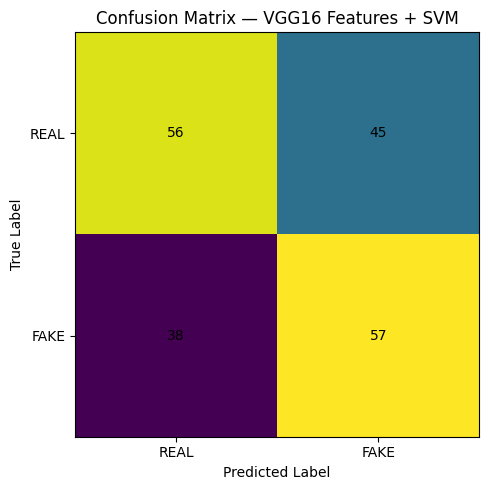

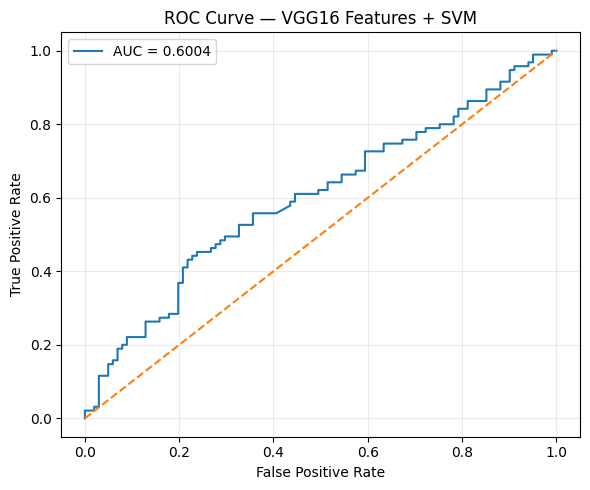

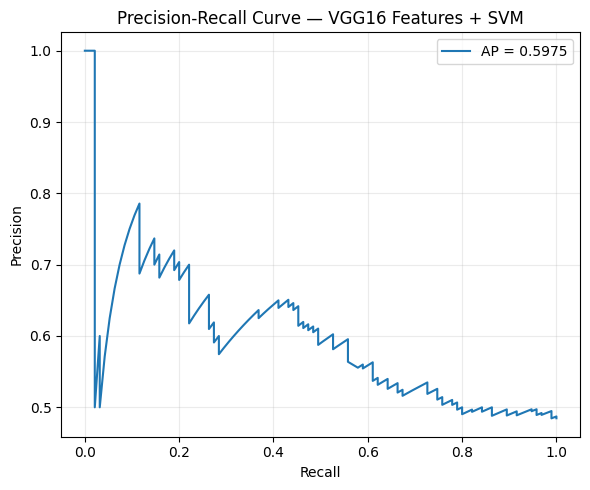

In [11]:

# ============================================================
# 12) FIGURES
# ============================================================

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
ax.imshow(cm)
ax.set_title("Confusion Matrix — VGG16 Features + SVM")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticks([0, 1], labels=["REAL", "FAKE"])
ax.set_yticks([0, 1], labels=["REAL", "FAKE"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

fpr, tpr, _ = roc_curve(y_test, test_fake_prob)
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
ax.plot(fpr, tpr, label=f"AUC = {frame_metrics['roc_auc']:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC Curve — VGG16 Features + SVM")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "roc_curve.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_fake_prob)
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
ax.plot(recall_curve, precision_curve, label=f"AP = {frame_metrics['average_precision']:.4f}")
ax.set_title("Precision-Recall Curve — VGG16 Features + SVM")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "precision_recall_curve.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


In [12]:

# ============================================================
# 13) METRICS / ENVIRONMENT / SUMMARY DOSYALARI
# ============================================================

metrics_payload = {
    "experiment": RUN_NAME,
    "region": "eyebrow",
    "feature_extractor": "VGG16 ImageNet / include_top=False / pooling=avg",
    "classifier": "SVM",
    "best_svm_params": best_params,
    "frame_level": frame_metrics,
    "video_level": video_metrics,
}

with open(METRICS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

gpu_devices = tf.config.list_physical_devices("GPU")
environment_payload = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "tensorflow": tf.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": __import__("sklearn").__version__,
    "gpu_devices": [str(x) for x in gpu_devices],
    "seed": SEED,
}

with open(OUTPUT_DIR / "environment.json", "w", encoding="utf-8") as f:
    json.dump(environment_payload, f, indent=2, ensure_ascii=False)

try:
    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"],
        text=True,
    )
except Exception as e:
    requirements = f"# pip freeze failed: {repr(e)}\n"

with open(OUTPUT_DIR / "requirements_lock.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

run_summary = {
    "status": "completed",
    "experiment_name": RUN_NAME,
    "dataset_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "dataset_counts": (
        inventory.groupby(["split", "class_name"])
        .size()
        .rename("count")
        .reset_index()
        .to_dict(orient="records")
    ),
    "feature_shapes": {
        "train": list(X_train.shape),
        "val": list(X_val.shape),
        "test": list(X_test.shape),
    },
    "best_svm_params": best_params,
    "final_fit_seconds": float(final_fit_seconds),
    "frame_level_metrics": frame_metrics,
    "video_level_metrics": video_metrics,
}

with open(OUTPUT_DIR / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2, ensure_ascii=False)

logger.info("Metrics and run metadata saved.")


2026-08-08 09:23:38 | INFO | Metrics and run metadata saved.


INFO:vgg16_svm_eyebrow:Metrics and run metadata saved.


In [13]:

# ============================================================
# 14) OUTPUT MANIFEST
# ============================================================

def sha256_file(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

manifest_rows = []

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file() and p.name != "output_manifest.csv":
        manifest_rows.append({
            "relative_path": str(p.relative_to(OUTPUT_DIR)),
            "size_bytes": p.stat().st_size,
            "sha256": sha256_file(p),
        })

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(
    OUTPUT_DIR / "output_manifest.csv",
    index=False,
    encoding="utf-8-sig",
)

display(manifest_df)

logger.info("Output manifest saved. Files=%d", len(manifest_df))


,relative_path,size_bytes,sha256
0,artifacts/dataset_inventory.csv,286038,a7aafc0e1787f7ec8c73e38c8cf2e532a4bc4b425aa0bb...
1,artifacts/feature_extractor.json,189,3e24659830a7fe9c4f675a5ed68f42293100b666367214...
2,artifacts/test_features.npz,289174,ad9d2b2fe368de1748ecb8bb62e1fe4620164a2e34fb46...
3,artifacts/train_features.npz,2258948,439215f15b46a5d9ad422155d9dd522911106f820b9072...
4,artifacts/val_features.npz,299807,35c39e63aaa61f302bc5143ee2e7e2e0a709ec96c46c38...
5,checkpoints/scaler.joblib,12903,ec4cdc7b3ecf6af5f8adb78a07070e75b3f7340b5bfbd5...
6,checkpoints/svm_model.joblib,6517259,800b6665ebe3e03fe06330c784334f4db93207509ba304...
7,config_resolved.yaml,765,a31e5c9b1d83c23c74f13329b7080510d5ed3814575579...
8,environment.json,375,a9de4c8d32d13fed5517cc3e15e0d475b9cbad4c0fe0fc...
9,figures/confusion_matrix.png,31058,747a4de13be29dc7c3182989569054e3107bbf926eaf85...


2026-08-08 09:23:44 | INFO | Output manifest saved. Files=20


INFO:vgg16_svm_eyebrow:Output manifest saved. Files=20



## Beklenen çıktı yapısı

```text
Sonuçlar/
└── VGG16_FeatureExtractor_SVM_Kas/
    ├── checkpoints/
    │   ├── scaler.joblib
    │   └── svm_model.joblib
    ├── logs/
    │   └── training.log
    ├── metrics/
    │   ├── metrics.json
    │   ├── classification_report.csv
    │   ├── confusion_matrix.csv
    │   └── svm_validation_search.csv
    ├── predictions/
    │   ├── test_predictions.csv
    │   └── video_level_predictions.csv
    ├── figures/
    │   ├── confusion_matrix.png
    │   ├── roc_curve.png
    │   └── precision_recall_curve.png
    ├── artifacts/
    │   ├── train_features.npz
    │   ├── val_features.npz
    │   ├── test_features.npz
    │   ├── dataset_inventory.csv
    │   └── feature_extractor.json
    ├── config_resolved.yaml
    ├── requirements_lock.txt
    ├── environment.json
    ├── run_summary.json
    └── output_manifest.csv
```

### Deney mantığı

- VGG16 yalnızca **feature extractor** olarak kullanılır.
- VGG16'nın ImageNet ağırlıkları donduruludur.
- `train`, `val`, `test` klasörleri **yeniden bölünmez**.
- SVM hiperparametreleri yalnızca `validation` seti kullanılarak seçilir.
- Final model, seçilen parametrelerle `train + val` üzerinde yeniden eğitilir.
- `test` seti yalnızca final değerlendirme için kullanılır.
